##  RL Model with HMM
###  Model with 1 hidden state
### State == 1 if action taken == outcome
### Reward == 1 if action == outcome

Q[a] Value:  0.2   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.36   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.488   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.59   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.672   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.0   Q[b] Value:  0.0 Action Taken:  A Outcome:  B
Q[a] Value:  0.0   Q[b] Value:  0.0 Action Taken:  A Outcome:  B
Q[a] Value:  0.0   Q[b] Value:  0.0 Action Taken:  B Outcome:  A
Q[a] Value:  0.0   Q[b] Value:  0.0 Action Taken:  A Outcome:  B
Q[a] Value:  0.538   Q[b] Value:  0.0 Action Taken:  B Outcome:  B
Q[a] Value:  0.63   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.704   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.763   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.811   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Value:  0.849   Q[b] Value:  0.0 Action Taken:  A Outcome:  A
Q[a] Val

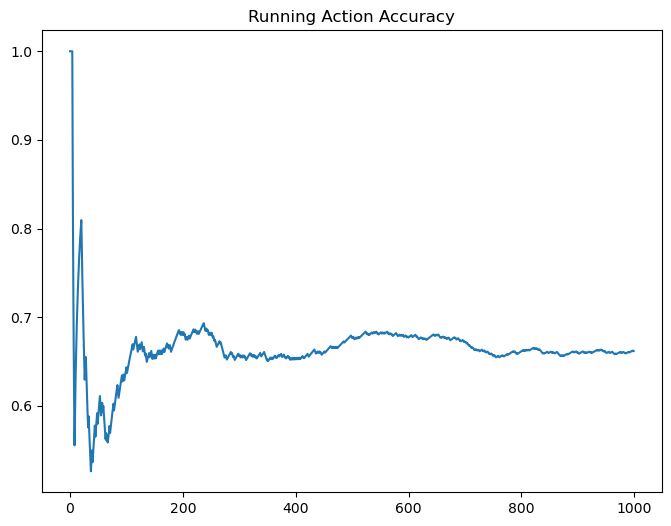

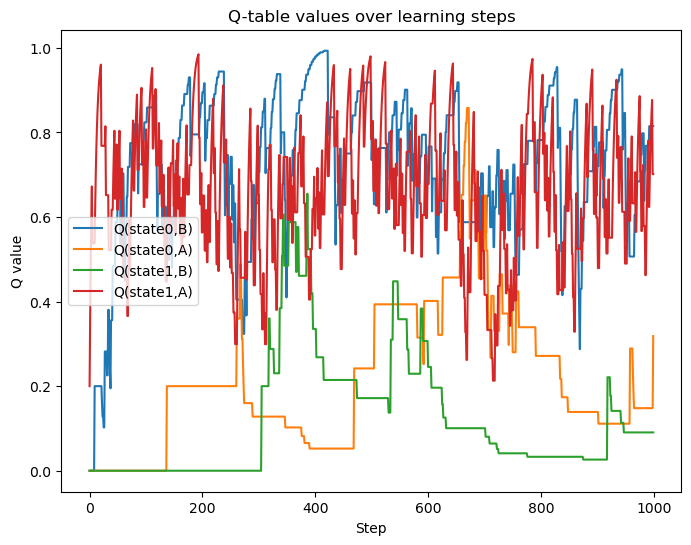

In [ ]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

max_steps = 1000
# Q_sa = [[0], [0], [0], [0]]
# Q_sb = [[0], [0], [0], [0]]
Q_sa = np.zeros((2, 2))
alpha = 0.2
p_a = 0.7
p_b = 0.3
B = 5.0
action_list = [1, 0]
action_a = 1
action_b = 0
action_dict = {1: "A", 0: "B"}
accurate_count_list = []

state = 1 if random.random() < p_a else 0    #70% of time state is = 1 initially
action = action_a
Q00_hist = []
Q01_hist = []
Q10_hist = []
Q11_hist = []

for step in range(0, max_steps):
    
    probs_a = (math.exp(B*Q_sa[state, action_a])) / float(np.sum((math.exp(B*Q_sa[state, action_a]), math.exp(B*Q_sa[state, action_b]))))
#    probs_b = (math.exp(B*Q_sb[state, action])) / float(np.sum((math.exp(B*Q_sa[state, action]), math.exp(B*Q_sb[state, action]))))
    probs_b = 1 - probs_a
    action = action_a if random.random() < probs_a else action_b

    if state == 1:
        outcome = 1 if random.random() < p_a else 0    #70% of time outcome = 1
        reward = 1 if action == outcome else 0
        # Agent over time converges to if I take action A, I get reward 0.7 of the time
        Q_sa[state, action] = Q_sa[state, action] + alpha*(reward-Q_sa[state, action])
        state = 1 if outcome == action else 0
    else:
        outcome = 1 if random.random() < p_b else 0    #30% of time outcome = 1
        reward = 1 if action == outcome else 0
        # Agent over time converges to if I take action A, I get reward 0.3 of the time, so it takes 
        # Action B to get back to state 1, its reward 0.7 of the time
        Q_sa[state, action] = Q_sa[state, action] + alpha*(reward-Q_sa[state, action])
        state = 1 if outcome == action  else 0

    Q00_hist.append(Q_sa[0,0])
    Q01_hist.append(Q_sa[0,1])
    Q10_hist.append(Q_sa[1,0])
    Q11_hist.append(Q_sa[1,1])
    #Q_sa[state, action] = Q_sa[state, action] + alpha*(reward-Q_sa[state, action])

    # elif action == action_b:
    #     Q_sb[state, action] = Q_sb[state, action] + alpha*(reward-Q_sb[state, action])


    print("Q[a] Value: ",round(Q_sa[state, 1], 3), "  Q[b] Value: ", round(Q_sa[state, 0],3), "Action Taken: ", action_dict[action], 
          "Outcome: ", action_dict[outcome])

    acc_check = 1 if action == outcome else 0
    accurate_count_list.append(acc_check)
    running_acc = np.cumsum(accurate_count_list) / np.arange(1, len(accurate_count_list)+1)


plt.figure(figsize=(8, 6))
plt.title("Running Action Accuracy")
plt.plot(running_acc)


plt.figure(figsize=(8,6))

plt.plot(Q00_hist, label="Q(state0,B)")
plt.plot(Q01_hist, label="Q(state0,A)")
plt.plot(Q10_hist, label="Q(state1,B)")
plt.plot(Q11_hist, label="Q(state1,A)")

plt.xlabel("Step")
plt.ylabel("Q value")
plt.title("Q-table values over learning steps")

plt.legend()
plt.show()

plt.show()
# avg_Q = total/1000
# print(avg_Q)

0 1 0 1
1 1 0 1
2 1 0 1
3 1 1 1
4 1 1 1
5 1 0 1
6 1 0 1
7 1 0 1
8 1 1 1
9 1 1 0
10 1 1 1
11 1 1 1
12 1 1 0
13 1 1 1
14 1 1 1
15 1 1 1
16 1 1 1
17 1 1 1
18 1 1 1
19 1 1 0
20 1 1 0
21 1 1 0
22 1 1 0
23 1 0 0
24 1 1 1
25 1 1 0
26 1 1 1
27 1 1 0
28 1 1 1
29 1 1 1
30 1 1 1
31 1 1 1
32 1 1 1
33 1 1 1
34 1 1 1
35 1 1 1
36 1 1 1
37 1 1 1
38 1 1 0
39 1 1 1
40 1 1 0
41 1 1 0
42 1 1 1
43 1 1 1
44 1 1 1
45 1 1 1
46 1 1 1
47 1 1 1
48 1 1 0
49 1 0 1
50 1 1 1
51 1 1 0
52 1 1 0
53 1 1 1
54 1 1 1
55 1 1 0
56 1 1 1
57 1 1 1
58 1 1 1
59 1 1 1
60 1 1 0
61 1 1 1
62 1 1 0
63 1 1 1
64 1 1 1
65 1 1 0
66 1 1 1
67 1 1 1
68 1 1 1
69 1 0 0
70 1 1 0
71 1 0 1
72 1 1 1
73 1 1 1
74 1 1 1
75 1 1 1
76 1 1 1
77 1 1 1
78 1 1 1
79 1 1 1
80 1 1 1
81 1 1 1
82 1 1 0
83 1 0 1
84 1 1 1
85 1 1 1
86 1 1 1
87 1 1 1
88 1 1 0
89 1 0 1
90 1 1 1
91 1 1 1
92 1 1 1
93 1 1 1
94 1 1 0
95 1 0 1
96 1 1 1
97 1 1 1
98 1 1 1
99 0 1 0
100 0 1 0
101 0 1 1
102 0 1 0
103 0 1 1
104 0 1 0
105 0 1 0
106 0 1 0
107 0 1 1
108 0 1 1
109 0 1 0
110 0 1 1


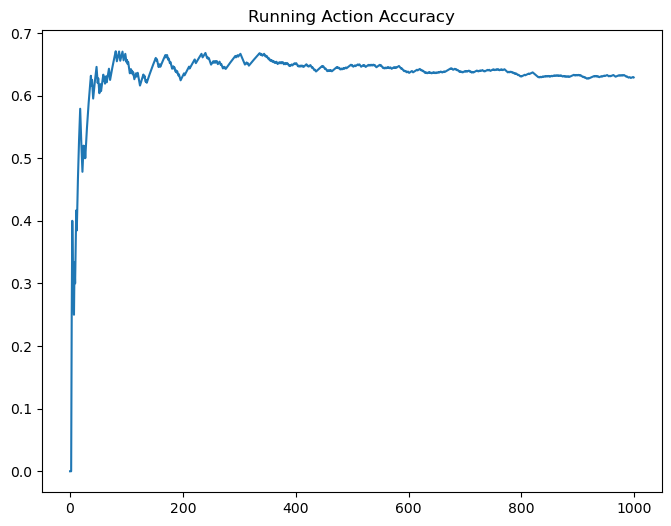

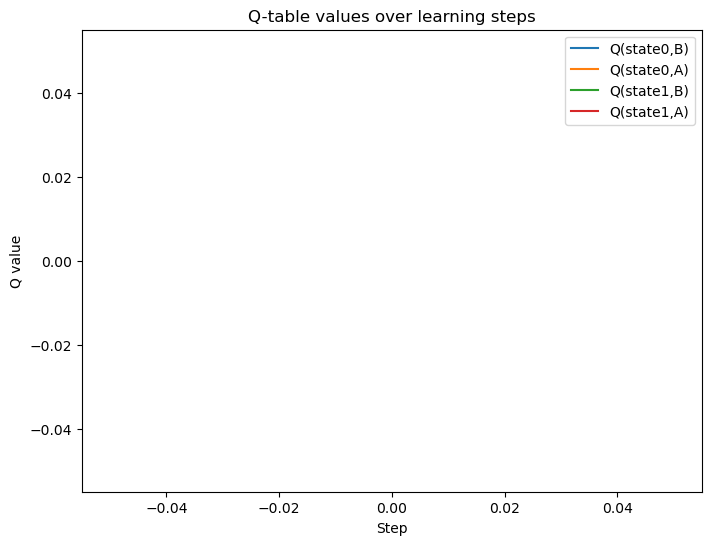

In [22]:
# Adding reversal learning

max_steps = 1000
# Q_sa = [[0], [0], [0], [0]]
# Q_sb = [[0], [0], [0], [0]]
Q_sa = np.zeros((2, 2))
alpha = 0.2
p_a = 0.7
p_b = 0.3
B = 5.0
action_list = [1, 0]
action_a = 1
action_b = 0
action_dict = {1: "A", 0: "B"}
accurate_count_list = []

state = 1 if random.random() < p_a else 0    #70% of time state is = 1 initially
action = action_a
Q00_hist = []
Q01_hist = []
Q10_hist = []
Q11_hist = []
Q_sa = np.zeros((2, ))
for step in range(0, max_steps):
    probs_a = (math.exp(B*Q_sa[action_a])) / float(np.sum((math.exp(B*Q_sa[action_a]), math.exp(B*Q_sa[action_b]))))
#    probs_b = (math.exp(B*Q_sb[state, action])) / float(np.sum((math.exp(B*Q_sa[state, action]), math.exp(B*Q_sb[state, action]))))
    probs_b = 1 - probs_a
    action = action_a if random.random() < probs_a else action_b

    if state == 1:
        outcome = 1 if random.random() < p_a else 0    #70% of time outcome = 1
    else:
        outcome = 1 if random.random() < p_b else 0    #30% of time outcome = 1
    
    reward = 1 if action == outcome else 0

    Q_sa[action] = Q_sa[action] + alpha*(reward-Q_sa[action])
    #state = 1 if random.random() < p_a else 0

    #state = 1 if outcome == action  else 0

    # Q00_hist.append(Q_sa[0,0])
    # Q01_hist.append(Q_sa[0,1])
    # Q10_hist.append(Q_sa[1,0])
    # Q11_hist.append(Q_sa[1,1])
    #Q_sa[state, action] = Q_sa[state, action] + alpha*(reward-Q_sa[state, action])

    # elif action == action_b:
    #     Q_sb[state, action] = Q_sb[state, action] + alpha*(reward-Q_sb[state, action])

    print(step, state, action, outcome)

    # print("Q[a] Value: ",round(Q_sa[state, 1], 3), "  Q[b] Value: ", round(Q_sa[state, 0],3), "Action Taken: ", action_dict[action], 
    #       "Outcome: ", action_dict[outcome])

    acc_check = 1 if action == outcome else 0
    accurate_count_list.append(acc_check)
    running_acc = np.cumsum(accurate_count_list) / np.arange(1, len(accurate_count_list)+1)


    # if step == 500:
    #     state = 1 - state

    if random.random() < 0.01:
        state = 1 - state

plt.figure(figsize=(8, 6))
plt.title("Running Action Accuracy")
plt.plot(running_acc)


plt.figure(figsize=(8,6))

plt.plot(Q00_hist, label="Q(state0,B)")
plt.plot(Q01_hist, label="Q(state0,A)")
plt.plot(Q10_hist, label="Q(state1,B)")
plt.plot(Q11_hist, label="Q(state1,A)")

plt.xlabel("Step")
plt.ylabel("Q value")
plt.title("Q-table values over learning steps")

plt.legend()
plt.show()

plt.show()
# avg_Q = total/1000
# print(avg_Q)

In [1]:
#Implementing in Gym:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class ReversalBanditEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.p_a = 0.7
        self.p_b = 0.3
        self.p_switch = 0.1

        # two actions: A or B
        self.action_space = spaces.Discrete(2)

        # observation doesn't reveal state
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(1,), dtype=np.float32
        )

        self.state = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.state = np.random.choice([0,1])
        obs = np.array([0.0], dtype=np.float32)

        return obs, {}

    def step(self, action):

        # generate outcome
        if self.state == 1:
            outcome = 1 if np.random.rand() < self.p_a else 0
        else:
            outcome = 1 if np.random.rand() < self.p_b else 0

        reward = 1 if action == outcome else 0

        # random rule reversal
        if np.random.rand() < self.p_switch:
            self.state = 1 - self.state

        obs = np.array([reward], dtype=np.float32)

        terminated = False
        truncated = False

        return obs, reward, terminated, truncated, {}

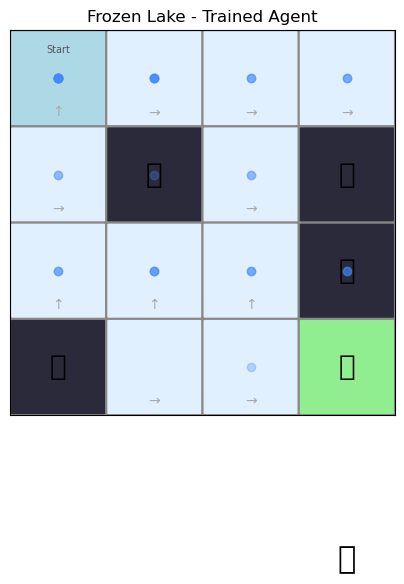

KeyboardInterrupt: 

C:\Users\cbail\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128371 (\N{HOLE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\cbail\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:82: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\cbail\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:82: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


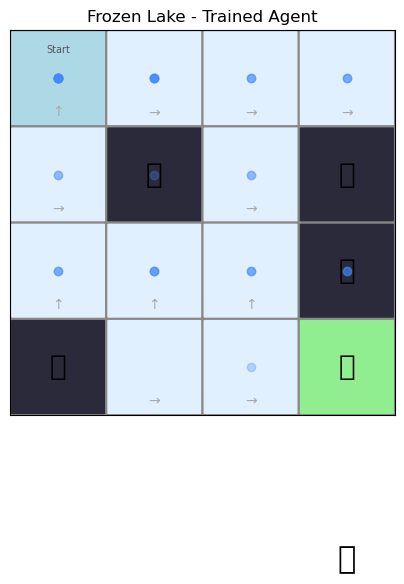

In [6]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation
from collections import deque
from IPython.display import HTML, display, clear_output
import time

# ============================================
# 1. TRAIN THE AGENT
# ============================================
env_name = "FrozenLake-v1"
map_size = "8x8"
is_slippery = True
learning_rate = 0.1
discount_factor = 0.99
epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.9995
max_episodes = 50000
max_steps_per_episode = 100
success_threshold = 0.78
window_size = 100

env = gym.make(env_name, map_name=map_size, is_slippery=is_slippery)
n_states = env.observation_space.n
n_actions = env.action_space.n
q_table = np.zeros((n_states, n_actions))

epsilon = epsilon_start
rewards_per_episode = []
success_window = deque(maxlen=window_size)

for episode in range(max_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        best_next = np.max(q_table[next_state])
        q_table[state, action] += learning_rate * (
            reward + discount_factor * best_next * (1 - terminated) - q_table[state, action]
        )

        state = next_state
        total_reward += reward
        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)
    success_window.append(total_reward)

    if len(success_window) == window_size:
        avg_success = np.mean(success_window)
        if (episode + 1) % 500 == 0:
            print(f"Episode {episode+1} | Avg success: {avg_success:.2f} | Epsilon: {epsilon:.4f}")
        if avg_success >= success_threshold:
            print(f"\nSolved at episode {episode+1}! Avg success rate: {avg_success:.2f}")
            break

env.close()

# --- Training plot ---
rolling_avg = np.convolve(rewards_per_episode, np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(10, 4))
plt.plot(rolling_avg)
plt.axhline(y=success_threshold, color='r', linestyle='--', label=f"Threshold ({success_threshold})")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("Training Progress")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 2. VISUAL REPLAY OF TRAINED AGENT
# ============================================

# Frozen lake map
lake_map = ["SFFF", "FHFH", "FFFH", "HFFG"]
grid_size = len(lake_map)

tile_colors = {
    'S': '#add8e6',  # light blue  - start
    'F': '#e0f0ff',  # pale blue   - frozen
    'H': '#2a2a3a',  # dark        - hole
    'G': '#90ee90',  # green       - goal
}

action_arrows = {
    0: '\u2190',  # LEFT
    1: '\u2193',  # DOWN
    2: '\u2192',  # RIGHT
    3: '\u2191',  # UP
}

def draw_frame(ax, agent_pos, trail, result_text=None):
    """Draw one frame of the frozen lake grid with the agent."""
    ax.clear()
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    for r in range(grid_size):
        for c in range(grid_size):
            tile = lake_map[r][c]
            color = tile_colors[tile]
            rect = patches.FancyBboxPatch(
                (c + 0.02, grid_size - r - 1 + 0.02), 0.96, 0.96,
                boxstyle="round,pad=0.02",
                facecolor=color, edgecolor='#888', linewidth=1.5
            )
            ax.add_patch(rect)

            # Label tiles
            if tile == 'H':
                ax.text(c + 0.5, grid_size - r - 0.5, '🕳️', ha='center', va='center', fontsize=20)
            elif tile == 'G':
                ax.text(c + 0.5, grid_size - r - 0.5, '⭐', ha='center', va='center', fontsize=20)
            elif tile == 'S':
                ax.text(c + 0.5, grid_size - r - 0.15, 'Start', ha='center', va='top', fontsize=7, color='#555')

            # Show policy arrow on frozen/start tiles
            s = r * grid_size + c
            if tile in ('F', 'S'):
                best_a = np.argmax(q_table[s])
                ax.text(c + 0.5, grid_size - r - 0.85, action_arrows[best_a],
                        ha='center', va='center', fontsize=10, color='#aaa')

    # Draw trail
    for (tr, tc) in trail:
        ax.plot(tc + 0.5, grid_size - tr - 0.5, 'o', color='#4488ff', markersize=6, alpha=0.3)

    # Draw agent
    ar, ac = agent_pos
    ax.text(ac + 0.5, grid_size - ar - 0.5, '🤖', ha='center', va='center', fontsize=22)

    if result_text:
        color = 'green' if 'Goal' in result_text else 'red'
        ax.set_title(result_text, fontsize=14, fontweight='bold', color=color)
    else:
        ax.set_title("Frozen Lake - Trained Agent", fontsize=12)


def replay_episode(q_table, run_number=1):
    """Run one episode and animate it frame by frame in the notebook."""
    env2 = gym.make(env_name, map_name=map_size, is_slippery=is_slippery)
    state, _ = env2.reset()
    
    trajectory = [state]
    for _ in range(max_steps_per_episode):
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env2.step(action)
        trajectory.append(state)
        if terminated or truncated:
            break
    env2.close()

    fig, ax = plt.subplots(figsize=(5, 5))

    for i, s in enumerate(trajectory):
        r, c = divmod(s, grid_size)
        trail = [(divmod(t, grid_size)) for t in trajectory[:i]]

        result_text = None
        if i == len(trajectory) - 1:
            tile = lake_map[r][c]
            if tile == 'G':
                result_text = f"Run {run_number}: Goal reached in {i} steps!"
            elif tile == 'H':
                result_text = f"Run {run_number}: Fell in hole at step {i}"

        draw_frame(ax, (r, c), trail, result_text)
        clear_output(wait=True)
        display(fig)
        time.sleep(0.4)

    time.sleep(1.0)
    plt.close(fig)

    return lake_map[r][c] == 'G'


# --- Run visual demos until the agent reaches the goal ---
print("Watching the trained agent play (keeps trying until it reaches the goal)...\n")
attempt = 0
while True:
    attempt += 1
    reached_goal = replay_episode(q_table, run_number=attempt)
    if reached_goal:
        print(f"\nAgent reached the goal on attempt {attempt}!")
        break
    else:
        print(f"Attempt {attempt}: fell in a hole, trying again...")
        time.sleep(0.5)
